In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('data/house_price_regression_dataset.csv')


In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [7]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [6]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

Text(0, 0.5, 'House Price Distribution')

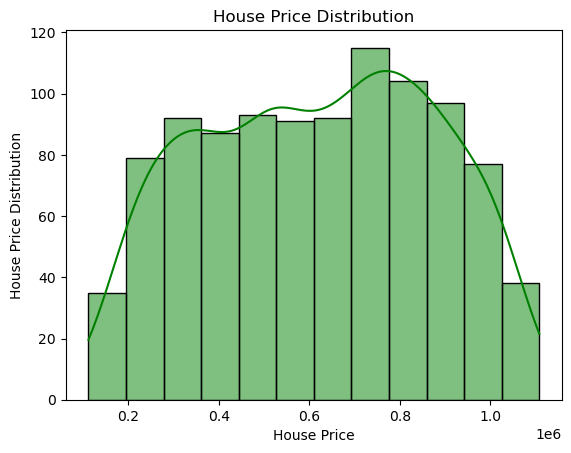

In [14]:
sns.histplot(df['House_Price'],kde=True,color='g')
plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("House Price Distribution")

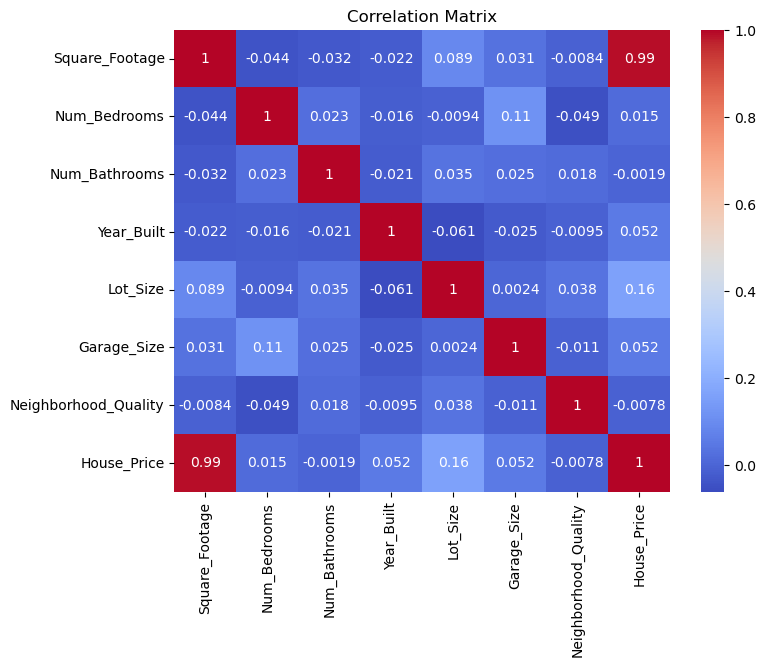

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

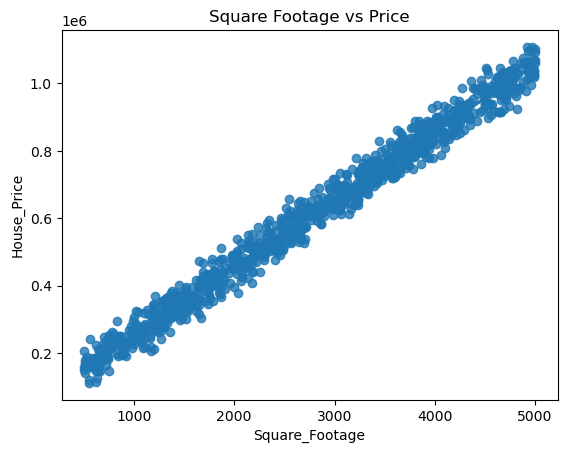

In [18]:
sns.regplot(x="Square_Footage", y="House_Price", data=df)
plt.title("Square Footage vs Price")
plt.show()


In [20]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("House_Price", axis=1)
y = df["House_Price"]

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Square_Footage          0.985864
Year_Built              0.005601
Lot_Size                0.005328
Num_Bedrooms            0.001604
Neighborhood_Quality    0.000689
Num_Bathrooms           0.000464
Garage_Size             0.000448
dtype: float64


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error



In [33]:
models = {
    "LinearRegression" : LinearRegression(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "RandomForestRegressor" : RandomForestRegressor(),
    "SVR" : SVR()}

    

In [34]:
X = df.drop('House_Price',axis=1)
y = df['House_Price']

In [35]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [40]:
def model_accuracy(models,x_train,x_test,y_train,y_test):
    for key,value in models.items():
        model = value
        model = model.fit(x_train,y_train)
        y_pred = model.predict(x_test)
        score = r2_score(y_pred,y_test)
        mean_square_error = mean_squared_error(y_pred,y_test)
        absolute_error = mean_absolute_error(y_pred,y_test)
        print(f"Accuracy for {key}")
        print("-------------------------------")
        print(f"R2 score {score}")
        print(f"Mean squared error {mean_square_error}")
        print(f"Mean absolute error {absolute_error}")


    

In [41]:
model_accuracy(models,x_train,x_test,y_train,y_test)

Accuracy for LinearRegression
-------------------------------
R2 score 0.9984045915312583
Mean squared error 101434798.50566754
Mean absolute error 8174.583600008711
Accuracy for DecisionTreeRegressor
-------------------------------
R2 score 0.9844181684761382
Mean squared error 999490018.1694629
Mean absolute error 24442.02713148545
Accuracy for RandomForestRegressor
-------------------------------
R2 score 0.9938011969885353
Mean squared error 391858417.6301956
Mean absolute error 16018.514556707758
Accuracy for SVR
-------------------------------
R2 score -3550036.3890503733
Mean squared error 64480847978.896
Mean absolute error 219380.3980007683


<h3>feature Engineering</h3>

In [42]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [43]:
    df["House_Age"] = 2026 - df["Year_Built"]

    df["SqFt_Per_Bedroom"] = (
        df["Square_Footage"] / (df["Num_Bedrooms"] + 1)
    )

    df["House_Density"] = (
        df["Square_Footage"] / (df["Lot_Size"] + 1)
    )

    df["Luxury_Score"] = (
        df["Square_Footage"] * df["Neighborhood_Quality"]
    )



In [44]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price',
       'House_Age', 'SqFt_Per_Bedroom', 'House_Density', 'Luxury_Score'],
      dtype='object')

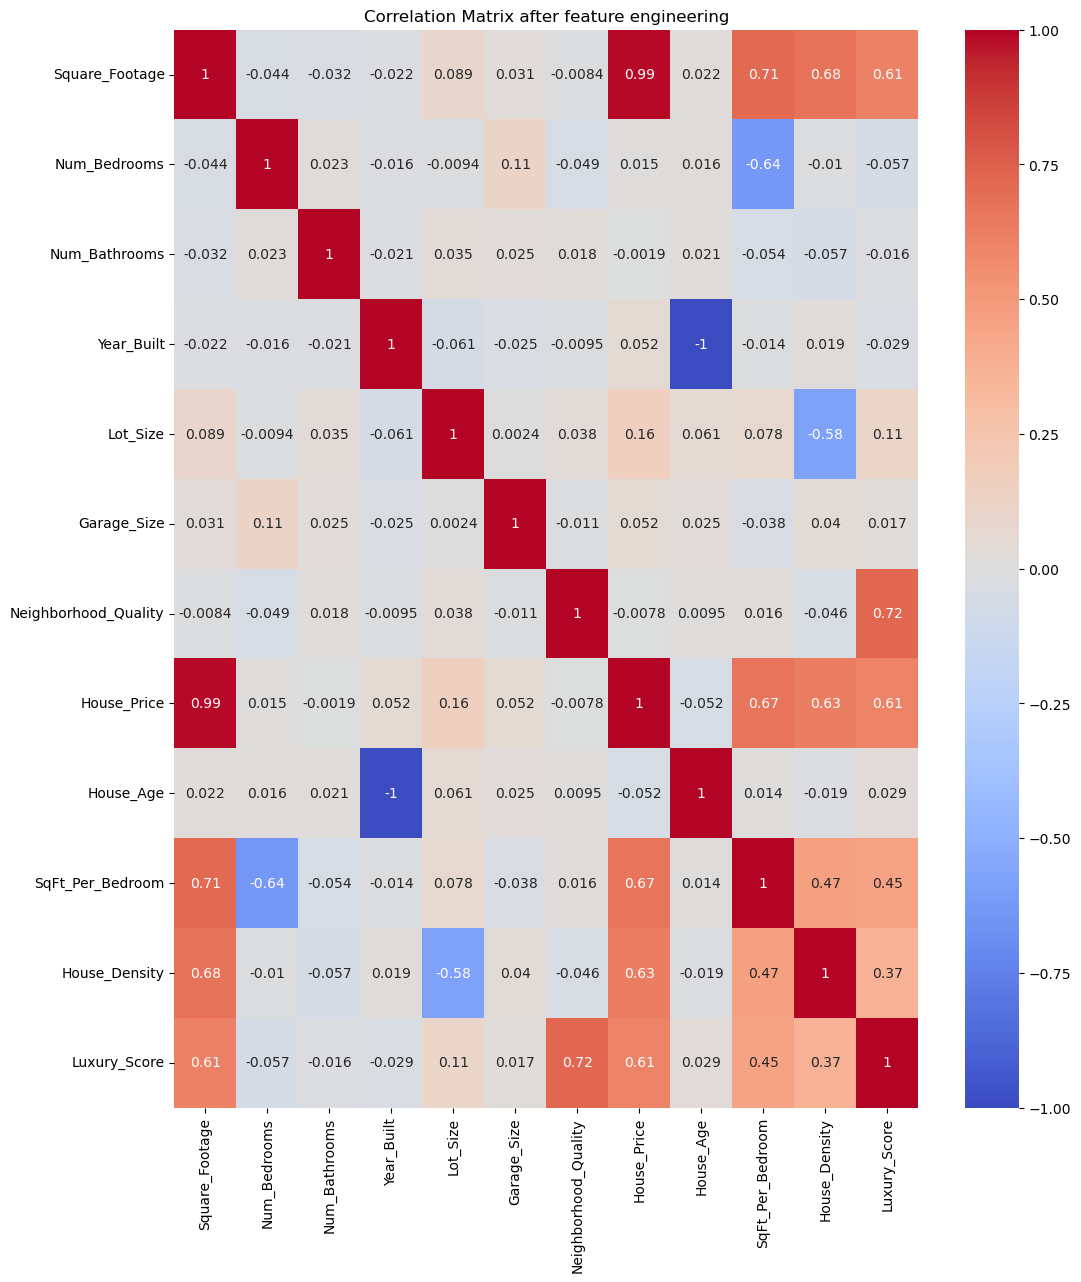

In [47]:
plt.figure(figsize=(12,14))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix after feature engineering")
plt.show()

In [49]:
x = df.drop('House_Price',axis=1)
y = df['House_Price']

In [50]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [51]:
model_accuracy(models,x_train,x_test,y_train,y_test)

Accuracy for LinearRegression
-------------------------------
R2 score 0.9984207202479204
Mean squared error 100439082.39961189
Mean absolute error 8159.279309817389
Accuracy for DecisionTreeRegressor
-------------------------------
R2 score 0.9856499046251962
Mean squared error 924708687.4797843
Mean absolute error 24332.468648887843
Accuracy for RandomForestRegressor
-------------------------------
R2 score 0.9935844374294112
Mean squared error 405112277.0145024
Mean absolute error 16332.589050827059
Accuracy for SVR
-------------------------------
R2 score -6164665.415169841
Mean squared error 64517968751.22025
Mean absolute error 219441.09104204288


In [55]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price',
       'House_Age', 'SqFt_Per_Bedroom', 'House_Density', 'Luxury_Score'],
      dtype='object')